# Ukraine Russia War Twitter Sentiment Analysis

In this project, we will develop a sentiment analysis model by analyzing tweets posted about the Russia-Ukraine war on Twitter.

<img src='https://middleeastoutlook.com/wp-content/uploads/2026/06/Header_UkraineInvasion_iStock2.jpg' width='750'>

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Reading Data

In [2]:
df=pd.read_csv('filename.csv')

### EDA

In [3]:
df.head()

,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,...,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
0,1630366235354451969,1630152070530576385,2023-02-28 00:36:15 UTC,2023-02-28,00:36:15,0,1493761817406894086,tomasliptai,Tomas Liptai,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'nazijaeger__', 'name': 'nazi...",NaN,NaN,NaN,NaN
1,1630366226424778753,1630366226424778753,2023-02-28 00:36:13 UTC,2023-02-28,00:36:13,0,1526694166662721536,paperfloure,Smell the roses,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
2,1630366225930027011,1630366225930027011,2023-02-28 00:36:13 UTC,2023-02-28,00:36:13,0,1053018392939167746,katetbar1,@etak,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
3,1630366223056662530,1630351686974992385,2023-02-28 00:36:12 UTC,2023-02-28,00:36:12,0,602371247,jlhrdhmom,JLHrdh,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'MainelifeR', 'name': 'Mainel...",NaN,NaN,NaN,NaN
4,1630366221483884545,1629903982255644672,2023-02-28 00:36:12 UTC,2023-02-28,00:36:12,0,1053594763214184448,phemikali,rolarkcybersecurity,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'Pottingpinks', 'name': 'GRS'...",NaN,NaN,NaN,NaN


In [4]:
df.tail()

,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,...,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
10009,1630331110415646721,1630305860298633216,2023-02-27 22:16:41 UTC,2023-02-27,22:16:41,0,998476071292035072,ahk14061,Andre🇳🇴🇺🇦,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'wallacemick', 'name': 'Mick ...",NaN,NaN,NaN,NaN
10010,1630331106305122304,1630202100369043459,2023-02-27 22:16:40 UTC,2023-02-27,22:16:40,0,1477276764908965889,marxistswon,Marxists Won,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'tom_username_', 'name': 'Tom...",NaN,NaN,NaN,NaN
10011,1630331106296844288,1630301689818275840,2023-02-27 22:16:40 UTC,2023-02-27,22:16:40,0,1616822734214037504,johngerver21,John Gerver,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'elonmusk', 'name': 'Elon Mus...",NaN,NaN,NaN,NaN
10012,1630331102480171009,1630181795101540357,2023-02-27 22:16:39 UTC,2023-02-27,22:16:39,0,25588052,late49er,Ben Davis,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'RonFilipkowski', 'name': 'Ro...",NaN,NaN,NaN,NaN
10013,1630331101817233414,1630248150954049537,2023-02-27 22:16:39 UTC,2023-02-27,22:16:39,0,1500491804176797700,dillengody,Gody van Dillen 🇺🇦 🇳🇱,NaN,...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'Lyla_lilas', 'name': 'Oriann...",NaN,NaN,NaN,NaN


In [5]:
df.shape

(10014, 36)

In [6]:
df.columns

Index(['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone',
       'user_id', 'username', 'name', 'place', 'tweet', 'language', 'mentions',
       'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count',
       'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'video',
       'thumbnail', 'near', 'geo', 'source', 'user_rt_id', 'user_rt',
       'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src',
       'trans_dest'],
      dtype='object')

In [7]:
df=df[["username", "tweet", "language"]]

In [8]:
df.head()

,username,tweet,language
0,tomasliptai,@nazijaeger__ @derwener @Anonymous9775 Russia ...,en
1,paperfloure,The Russia HAARP which could destroy USA in on...,en
2,katetbar1,Putin gives Steven Seagal Russia&amp;#8217;s O...,en
3,jlhrdhmom,@MainelifeR @BaddCompani It’s ALWAYS PROJECTIO...,en
4,phemikali,@Pottingpinks @mfa_russia @mod_russia @mil_his...,en


In [9]:
df.isnull().sum()

username    0
tweet       0
language    0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10014 entries, 0 to 10013
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   username  10014 non-null  object
 1   tweet     10014 non-null  object
 2   language  10014 non-null  object
dtypes: object(3)
memory usage: 234.8+ KB


In [11]:
df["language"].value_counts()

language
en     8858
pt      440
it      194
qme     105
und      60
in       47
ru       44
ja       42
es       36
ca       20
qht      20
th       19
fr       18
de       14
ko        9
vi        8
nl        8
ro        7
fi        7
ar        6
zxx       6
uk        6
cs        6
zh        5
pl        5
qam       4
tl        4
da        3
eu        2
no        2
hi        2
tr        2
hu        1
cy        1
lv        1
el        1
bn        1
Name: count, dtype: int64

In [12]:
df[df['language']=='tr']

,username,tweet,language
459,murfo1211,@RussianEmbassy @KremlinRussia_E @mfa_russia @...,tr
8542,ddgrubu,Rus petrolü Kuzey Afrika'da alıcı bulunuyor. B...,tr


##### To Do For NLP
Read dataset

Convert text to lowercase

Remove punctuation

Remove numbers / digits

Remove newlines and carriage returns

Remove stop words

Tokenize text

Perform stemming / lemmatization

Vectorize text

Apply TF-IDF (Term Frequency - Inverse Document Frequency)

In [13]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download required NLTK data (punkt_tab added)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize objects and variables
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
rare_words = set()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [14]:
# 1. Text Cleaning 
df['tweet'] = df['tweet'].str.lower()  # convert text to lowercase
df['tweet'] = df['tweet'].str.replace('http\S+|www\S+', '', regex=True)  # remove urls
df['tweet'] = df['tweet'].str.replace('[^\w\s]', '', regex=True)  # remove punctuation
df['tweet'] = df['tweet'].str.replace('\d+', '', regex=True)  # remove numbers / digits
df['tweet'] = df['tweet'].str.replace('\n|\r', ' ', regex=True)  # remove newlines & carriage returns
df['tweet'] = df['tweet'].str.replace('\s+', ' ', regex=True).str.strip()  # remove extra whitespaces

# 2. Tokenization & Filtering
df['tweet'] = df['tweet'].apply(word_tokenize)  # tokenize text
df['tweet'] = df['tweet'].apply(lambda x: [w for w in x if w not in stop_words])  # remove stop words
df['tweet'] = df['tweet'].apply(lambda x: [w for w in x if w not in rare_words])  # remove rare words

# 3. Lemmatization 
df['tweet'] = df['tweet'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])  # perform lemmatization

# 4. Rejoin Tokens & Vectorization
df['tweet'] = df['tweet'].apply(lambda x: ' '.join(x))  # join tokens to string
x=TfidfVectorizer().fit_transform(df['tweet'])  # vectorize text with tf-idf

In [15]:
df['tweet'][66]

'grumpy_us stationcdrkelly thank deleting tweet hope also admit wrong zelensky bloodthirsty jewish nazi wanted invade russia would want happen got invaded u would beg peace even mean land fight back'

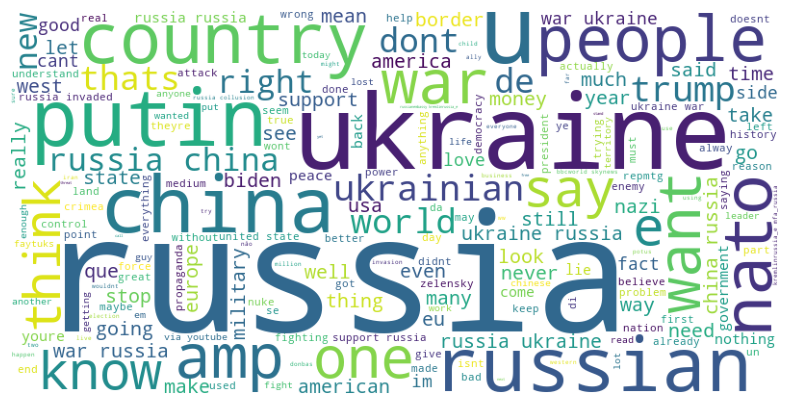

In [16]:
from wordcloud import WordCloud

text = ' '.join(df['tweet'].dropna())
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [17]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
sentiments = SentimentIntensityAnalyzer()
df["Positive"] = [sentiments.polarity_scores(i)["pos"] for i in df["tweet"]]
df["Negative"] = [sentiments.polarity_scores(i)["neg"] for i in df["tweet"]]
df["Neutral"] = [sentiments.polarity_scores(i)["neu"] for i in df["tweet"]]
df=df[["tweet", "Positive", "Negative", "Neutral"]]

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [18]:
df.head()

,tweet,Positive,Negative,Neutral
0,nazijaeger__ derwener anonymous russia place s...,0.231,0.000,0.769
1,russia haarp could destroy usa one fell swoop ...,0.000,0.416,0.584
2,putin give steven seagal russiaamps order frie...,0.326,0.000,0.674
3,mainelifer baddcompani always projection russia,0.000,0.000,1.000
4,pottingpinks mfa_russia mod_russia mil_hist_rf...,0.068,0.078,0.854


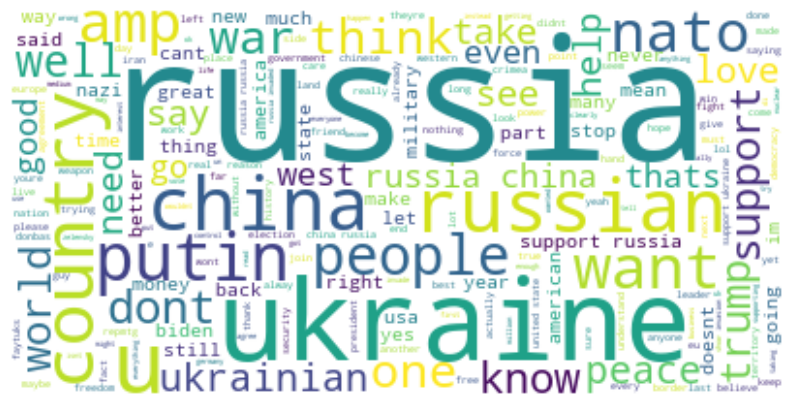

In [19]:
from wordcloud import WordCloud, STOPWORDS
positive =' '.join([i for i in df['tweet'][df['Positive'] > df["Negative"]]])
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(positive)
plt.figure( figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

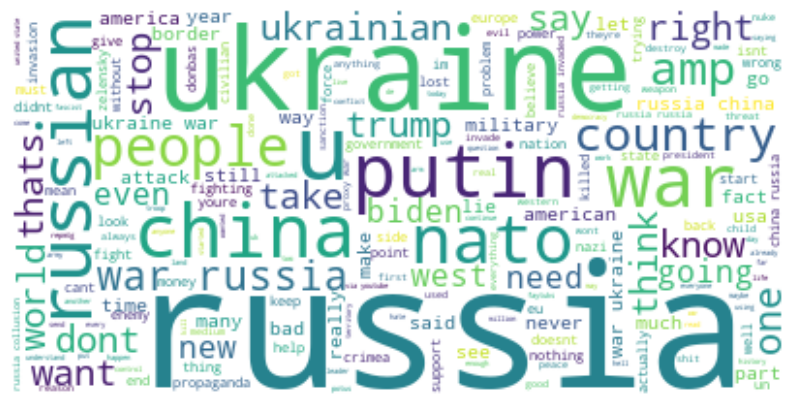

In [20]:
negative =' '.join([i for i in df['tweet'][df['Negative'] > df["Positive"]]])
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(negative)
plt.figure( figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [21]:
#!pip install spacy
#!python -m spacy download en_core_web_sm

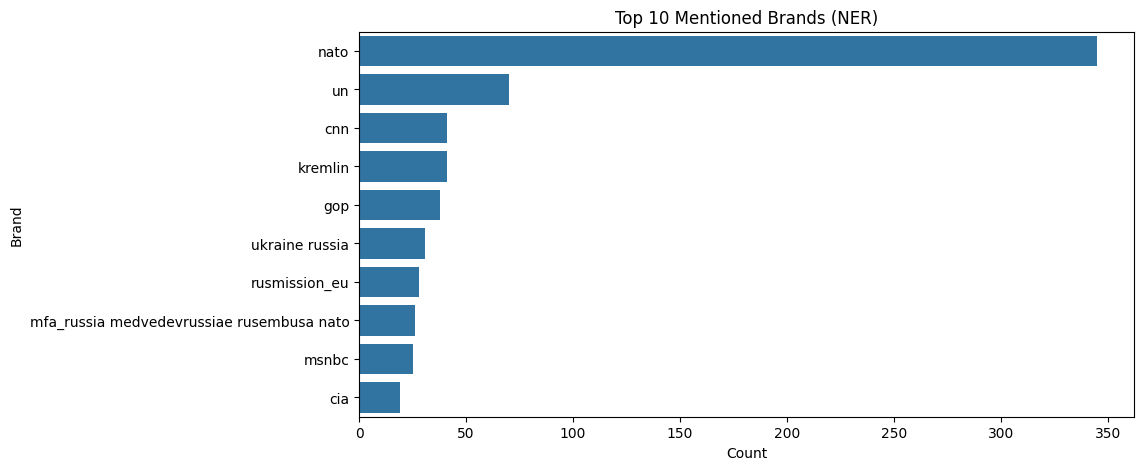

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from collections import Counter

# Load spacy fast model
nlp = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer'])

# Sample 5k rows for quick NER processing
sample_text = df['tweet'].dropna().sample(5000, random_state=42)

# Extract ORG (Brand/Company) entities
orgs = []
for doc in nlp.pipe(sample_text, batch_size=250):
    orgs.extend([ent.text.lower() for ent in doc.ents if ent.label_ == 'ORG'])

# Plot Top 10 Most Mentioned Brands
top_orgs = pd.DataFrame(Counter(orgs).most_common(10), columns=['Brand', 'Count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=top_orgs, x='Count', y='Brand')
plt.title('Top 10 Mentioned Brands (NER)')
plt.show()

In [23]:
df.columns

Index(['tweet', 'Positive', 'Negative', 'Neutral'], dtype='object')

In [24]:
x=df['tweet']

In [25]:
y = df[['Positive', 'Negative', 'Neutral']].idxmax(axis=1)

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
x = cv.fit_transform(x).toarray()

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=15, random_state=42)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb = GradientBoostingClassifier()
kn = KNeighborsClassifier()
ab = AdaBoostClassifier()
mn = MultinomialNB()

def algo_test(x, y):
    models = [b, l, d, r, gb, kn, ab, mn]
    names = ["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl = []

    print("Data is ready, testing models...")
    for model in models:
        print(f"Training {model} model!...")
        model = model.fit(x_train, y_train)
        prediction = model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, prediction))
        precision.append(precision_score(y_test, prediction, average="micro"))
        recall.append(recall_score(y_test, prediction, average="micro"))
        f1.append(f1_score(y_test, prediction, average="micro"))
        print(confusion_matrix(y_test, prediction))

    print("Training completed.")
    
    metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=names)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"] = mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("Best performing model: ", metrics.iloc[0].name)
    best_model = metrics.iloc[0, -1]
    prediction = best_model.predict(np.array(x_test) if best_model == kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, prediction))
    print("Classification Report:")
    print(classification_report(y_test, prediction))
    print("Other Models:")
    
    return metrics.drop("Model", axis=1)

In [31]:
algo_test(x,y) 

Data is ready, testing models...
Training BernoulliNB() model!...
[[   0   75    0]
 [   6 1862    0]
 [   0   60    0]]
Training LogisticRegression() model!...
[[  27   47    1]
 [  14 1851    3]
 [   1   47   12]]
Training DecisionTreeClassifier() model!...
[[  23   50    2]
 [  60 1742   66]
 [   4   43   13]]
Training RandomForestClassifier() model!...
[[  13   62    0]
 [   4 1830   34]
 [   1   50    9]]
Training GradientBoostingClassifier() model!...
[[   9   66    0]
 [   4 1860    4]
 [   0   57    3]]
Training KNeighborsClassifier() model!...
[[  29   43    3]
 [ 106 1602  160]
 [   4   46   10]]
Training AdaBoostClassifier() model!...
[[   0   75    0]
 [   0 1868    0]
 [   0   60    0]]
Training MultinomialNB() model!...
[[   6   69    0]
 [  38 1806   24]
 [   1   58    1]]
Training completed.
Best performing model:  LogisticRegression
Confusion Matrix:
[[  27   47    1]
 [  14 1851    3]
 [   1   47   12]]
Classification Report:
              precision    recall  f1-scor

,Accuracy,Precision,Recall,F1
LogisticRegression,0.943585,0.943585,0.943585,0.943585
GradientBoostingClassifier,0.934598,0.934598,0.934598,0.934598
AdaBoostClassifier,0.932601,0.932601,0.932601,0.932601
BernoulliNB,0.929606,0.929606,0.929606,0.929606
RandomForestClassifier,0.924613,0.924613,0.924613,0.924613
MultinomialNB,0.905142,0.905142,0.905142,0.905142
DecisionTreeClassifier,0.887668,0.887668,0.887668,0.887668
KNeighborsClassifier,0.819271,0.819271,0.819271,0.819271


In [32]:
import joblib
joblib.dump(l, 'best_model.pkl')
joblib.dump(cv, 'vectorizer.pkl')


['vectorizer.pkl']

Among the evaluated classification models, Logistic Regression achieved the highest overall performance with an accuracy, precision, recall, and F1-score of approximately 94.36%, making it the optimal choice for classifying Twitter sentiment regarding the Ukraine-Russia war.